In [24]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob

import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [25]:
pgroup = 'p23106'
runlist = [102]
#runlist = np.arange(180, 186)

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 102


100%|██████████| 77/77 [00:37<00:00,  2.06it/s]


In [163]:
#plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='126', withTT=False, bins=100, figsize=(10, 3))

In [26]:
ui, out  = Rebin_widget(data=data)
ui


In [224]:
### --- To run manually instead of ui --- ###

# base_params = {'izero': 'diode3', 'quantile': 0.7, 'TT': '124', 'YAGscan': False, 'withTT': False}
# meta_params = {'signal1': diode1', 'signal2': 'diode2'}

# results1 = Rebin_with_scanvar_and_filter(signal='diode1', data=data, **base_params)
# results2 = Rebin_with_scanvar_and_filter(signal='diode2', data=data, **base_params)
# out['signal1'] = {"results": results1, "params": base_params, "which": 'diode1'}
# out['signal2'] = {"results": results2, "params": base_params, "which": 'diode2'}

In [27]:
data_plot1 = out["signal1"]
data_plot2 = out["signal2"]

Data saved in /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0102/


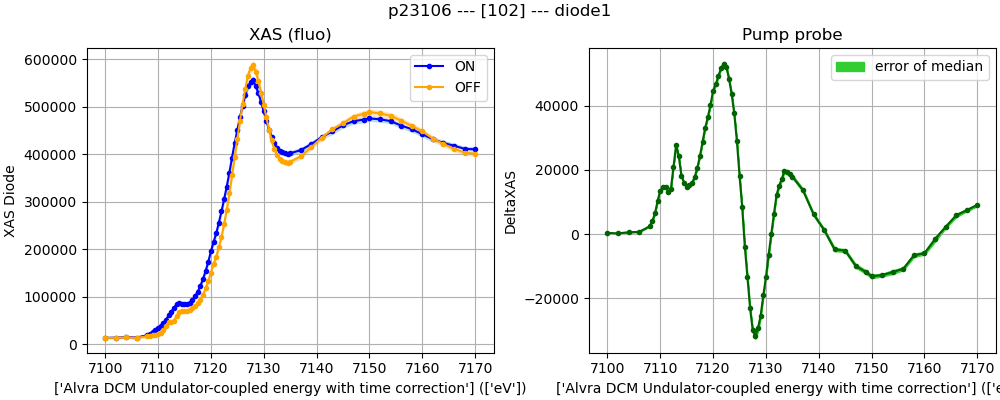

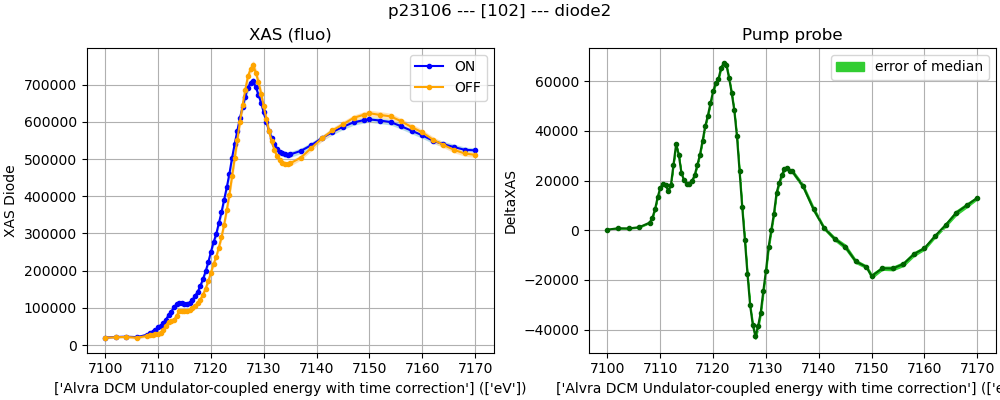

In [28]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2)

fig, axes = plotter.energy_scans(data_plot1, meta, errbars=False)
fig, axes = plotter.energy_scans(data_plot2, meta, errbars=False)


Data saved in /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0102/


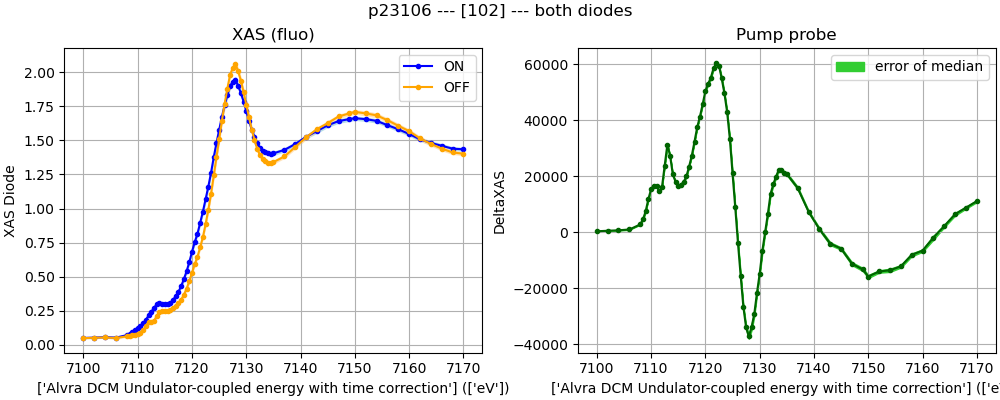

In [29]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=data_plot_both)
fig, axes = plotter.energy_scans(data_plot_both, meta, errbars=False)


# Overlay data with UI

In [5]:
pgroup = 'p23106'
which_plot = 'both'

#LoadDir = '/sf/alvra/data/{}/work/Reduced_data_test/'.format(pgroup)
LoadDir = SaveDir
selector = RunSelectorUI(LoadDir)

NameError: name 'SaveDir' is not defined

Loaded __both diodes__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0036/data.npz
Loaded __both diodes__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0035/data.npz
Loaded __both diodes__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0034/data.npz


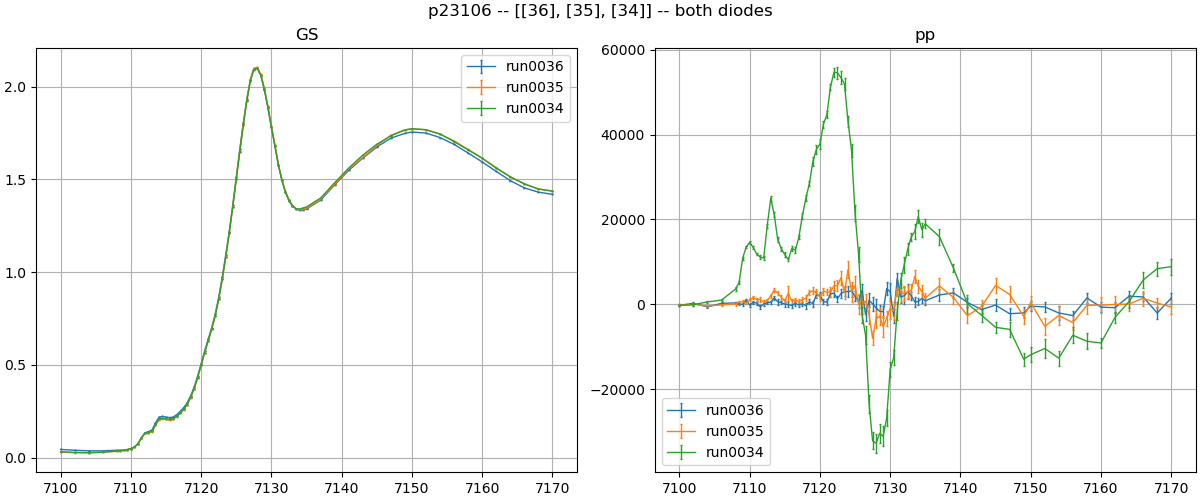

In [258]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp_boot']
    #err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS, 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, err_pp, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'lower left')
ax3.set_title('pp')
ax3.grid()
plt.show()

# Overlay data "manually"

In [30]:
pgroup = 'p23106'
runlist2load = [86,98,102]

which_plot = 'plot1' #plot_both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
#selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0086/data.npz
Loaded __diode1__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0098/data.npz
Loaded __diode1__ from: /sf/alvra/data/p23106/work/Reduced_data/_singlerun/run0102/data.npz


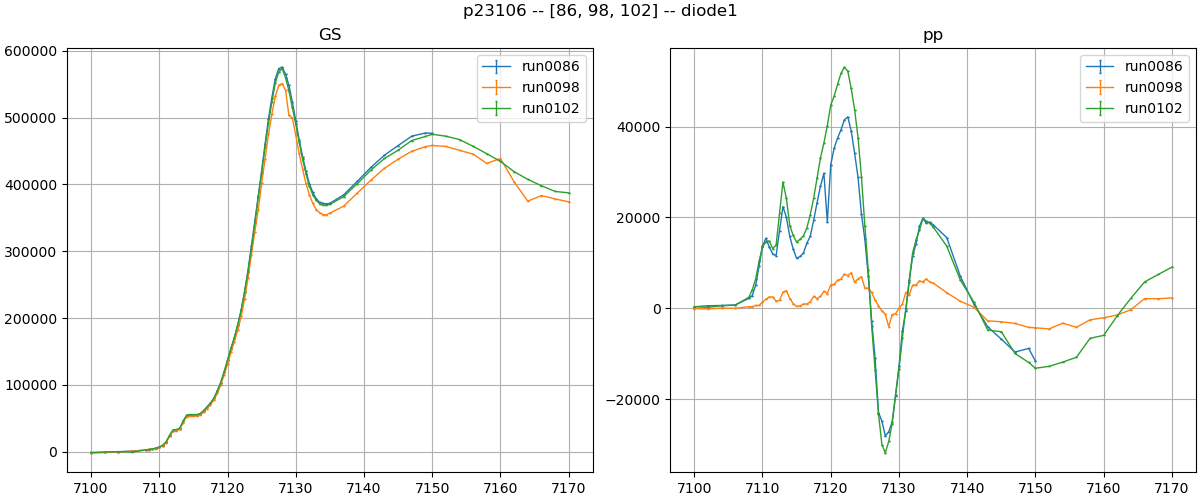

In [31]:
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
ax3.set_title('pp')
ax3.grid()
plt.show()
